In [5]:
import torch
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

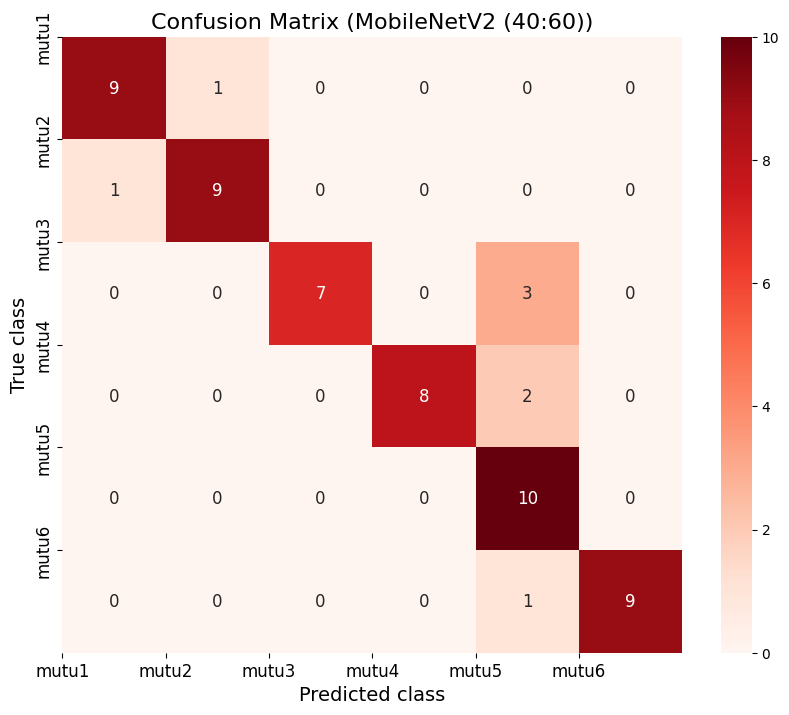

Model: MobileNetV2 (40:60)
Accuracy: 0.8666666666666667
Precision: [0.9   0.9   1.    1.    0.625 1.   ]
Recall: [0.9 0.9 0.7 0.8 1.  0.9]
F1 Score: [0.9        0.9        0.82352941 0.88888889 0.76923077 0.94736842]
Average Prediction Time per Image: 0.1983741283416748 seconds




/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


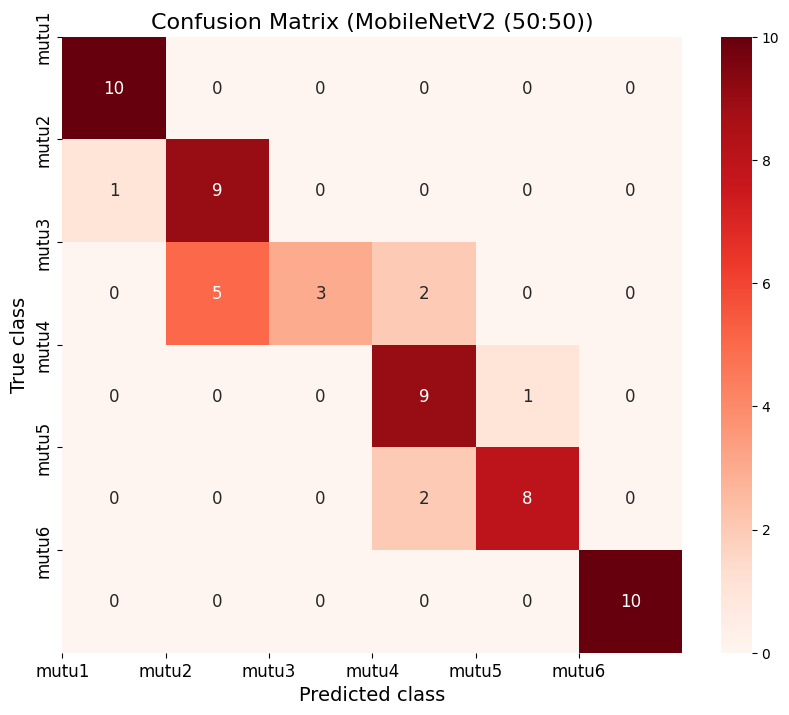

Model: MobileNetV2 (50:50)
Accuracy: 0.8166666666666667
Precision: [0.90909091 0.64285714 1.         0.69230769 0.88888889 1.        ]
Recall: [1.  0.9 0.3 0.9 0.8 1. ]
F1 Score: [0.95238095 0.75       0.46153846 0.7826087  0.84210526 1.        ]
Average Prediction Time per Image: 0.18440022865931194 seconds




/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


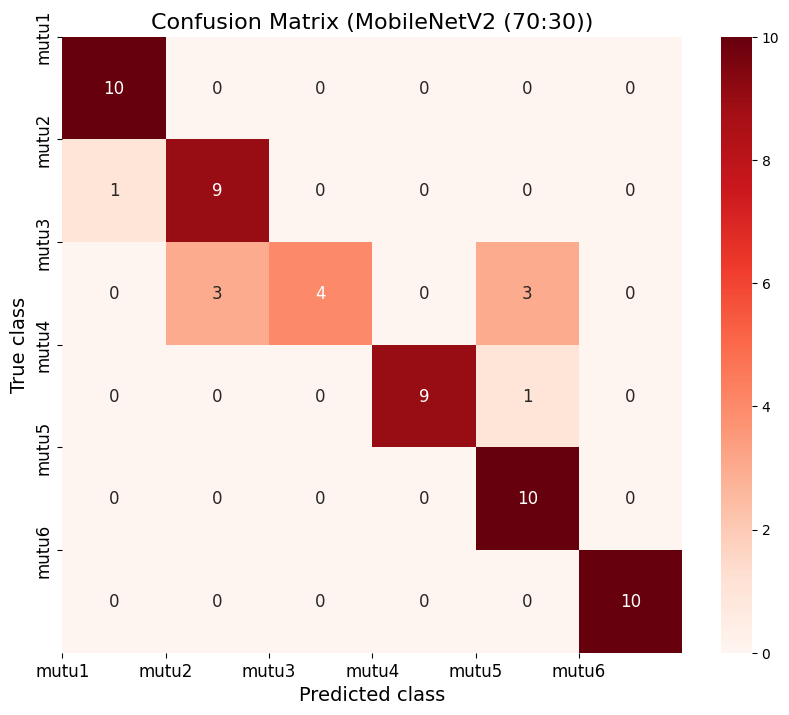

Model: MobileNetV2 (70:30)
Accuracy: 0.8666666666666667
Precision: [0.90909091 0.75       1.         1.         0.71428571 1.        ]
Recall: [1.  0.9 0.4 0.9 1.  1. ]
F1 Score: [0.95238095 0.81818182 0.57142857 0.94736842 0.83333333 1.        ]
Average Prediction Time per Image: 0.18592029015223185 seconds




/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


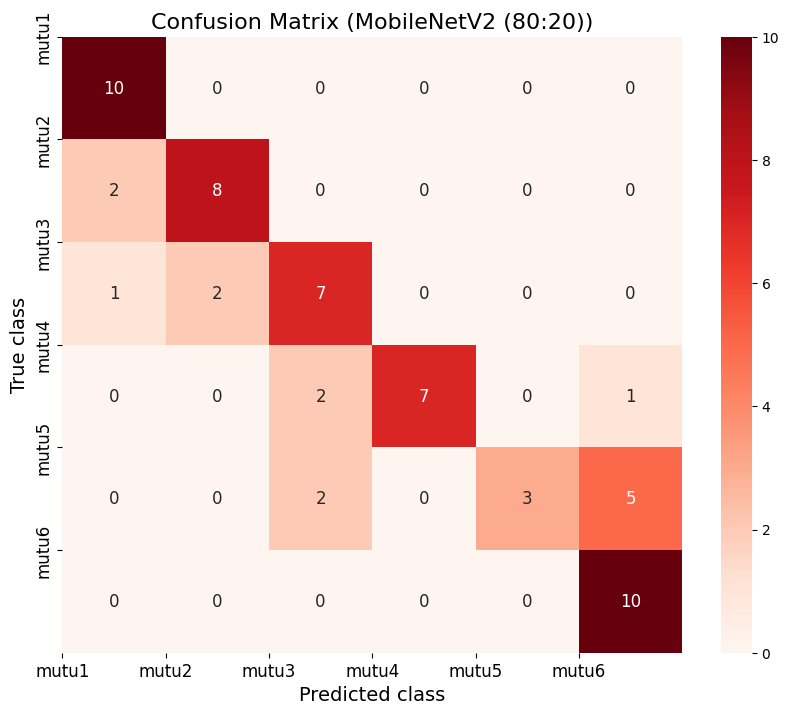

Model: MobileNetV2 (80:20)
Accuracy: 0.75
Precision: [0.76923077 0.8        0.63636364 1.         1.         0.625     ]
Recall: [1.  0.8 0.7 0.7 0.3 1. ]
F1 Score: [0.86956522 0.8        0.66666667 0.82352941 0.46153846 0.76923077]
Average Prediction Time per Image: 0.19161571661631266 seconds




In [6]:
import os
from torchvision import transforms
from PIL import Image
import itertools
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v2
import time  # Import modul time

# Definisikan transformasi
predict_transform = transforms.Compose([
    transforms.Resize(230),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Definisikan model CustomMobileNetV2
class CustomMobileNetV2(nn.Module): 
    def __init__(self, output_size): 
        super().__init__()
        self.mnet = mobilenet_v2(pretrained=True)
        self.freeze()
        self.mnet.classifier = nn.Sequential( 
            nn.Linear(1280, output_size),
            nn.LogSoftmax(dim=1)
        )
        
    def forward(self, x):
        return self.mnet(x)
    
    def freeze(self):
        for param in self.mnet.parameters(): 
            param.requires_grad= False
    
    def unfreeze(self):
        for param in self.mnet.parameters():
            param.requires_grad= True

class_names = ['mutu1', 'mutu2', 'mutu3', 'mutu4', 'mutu5', 'mutu6']

# Persiapkan daftar path dan weight untuk setiap model CNN
model_paths = ['/kaggle/input/cnn-mobilenetv2-weight-arabica/weight_cnn/mobilenetv2(4060).pth',
               '/kaggle/input/cnn-mobilenetv2-weight-arabica/weight_cnn/mobilenetv2(5050).pth',
               '/kaggle/input/cnn-mobilenetv2-weight-arabica/weight_cnn/mobilenetv2(7030).pth',
               '/kaggle/input/cnn-mobilenetv2-weight-arabica/weight_cnn/mobilenetv2(8020).pth']

# Inisialisasi daftar nama model dan label weight
model_names = ['MobileNetV2 (40:60)', 'MobileNetV2 (50:50)', 'MobileNetV2 (70:30)', 'MobileNetV2 (80:20)']

# Definisikan fungsi untuk prediksi
def predict_image(image_path, model, class_names):
    # Muat dan transformasi gambar
    image = Image.open(image_path).convert('RGB')
    image = predict_transform(image).unsqueeze(0).to(device)
    
    # Lakukan prediksi
    with torch.no_grad():
        output = model(image)
        _, predicted_class_idx = torch.max(output, 1)
    
    predicted_class_label = class_names[predicted_class_idx.item()]
    return predicted_class_label

# Persiapkan daftar gambar untuk prediksi
pred_class_path = '/kaggle/input/prediction-arabica-class/pred_class'
pred_list = []

for root, dirs, files in os.walk(pred_class_path):
    for file in files:
        if file.endswith('.jpg'):
            pred_list.append((os.path.join(root, file), class_names.index(root.split('/')[-1])))

pred_list.sort(key=lambda x: x[1])
pred_list = [item[0] for item in pred_list]

# Buat daftar label aktual
actual_labels = [name for name in itertools.chain.from_iterable(itertools.repeat(class_name, 10) for class_name in class_names)]

# Daftar label yang diprediksi
predicted_labels = []

# Inisialisasi daftar matriks kebingungan dan evaluasi kinerja
confusion_matrices = []
accuracies = []
precisions = []
recalls = []
f1_scores = []
prediction_times = []  # List to store prediction times

# Hitung matriks kebingungan dan evaluasi kinerja
def calculate_confusion_matrix(actual_labels, predicted_labels):
    cm = confusion_matrix(actual_labels, predicted_labels)
    return cm

# Iterasi melalui setiap path model dan lakukan prediksi
for path, name in zip(model_paths, model_names):
    # Inisialisasi model
    output_size = 6 
    model = CustomMobileNetV2(output_size).to(device)
    # Muat state dict dari file .pth
    model.load_state_dict(torch.load(path, map_location=device))
    # Set model ke mode evaluasi
    model.eval()
    # Buat daftar label yang diprediksi
    predicted_labels = []
    # Buat daftar waktu prediksi
    times = []
    # Iterasi melalui gambar-gambar di path dan lakukan prediksi
    for image_path in pred_list:
        start_time = time.time()  # Start time
        predicted_label = predict_image(image_path, model, class_names)
        end_time = time.time()  # End time
        times.append(end_time - start_time)  # Calculate prediction time
        predicted_labels.append(predicted_label)
    # Hitung matriks kebingungan dan evaluasi kinerja
    cm = calculate_confusion_matrix(actual_labels, predicted_labels)
    accuracy = np.trace(cm) / np.sum(cm)
    precision = np.diag(cm) / np.sum(cm, axis=0)
    recall = np.diag(cm) / np.sum(cm, axis=1)
    f1_score = 2 * (precision * recall) / (precision + recall)
    # Tambahkan hasil ke daftar
    confusion_matrices.append(cm)
    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1_score)
    prediction_times.append(np.mean(times))  # Store the average prediction time
    # Tampilkan matriks kebingungan
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", annot_kws={"size": 12})
    plt.xlabel("Predicted class", fontsize=14)
    plt.ylabel("True class", fontsize=14)
    plt.title(f"Confusion Matrix ({name})", fontsize=16)
    plt.xticks(range(len(class_names)), class_names, rotation=0, fontsize=12)
    plt.yticks(range(len(class_names)), class_names, fontsize=12)
    plt.show()
    # Tampilkan evaluasi kinerja
    print(f"Model: {name}")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1_score)
    print(f"Average Prediction Time per Image: {np.mean(times)} seconds")  # Print average prediction time
    print("\n")
